# Fase 1: Entrenamiento SciBETO para Tarea 2

Este notebook se enfoca en ajustar el modelo Transformer SciBETO para la detección de contribuciones científicas (`tarea2_role`).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import pandas as pd
import json

import matplotlib.pyplot as plt
import seaborn as sns

## 1. Carga de Archivos JSONL
Cargamos los conjuntos de entrenamiento y validación de la Tarea 2.

In [26]:
import pandas as pd
import json

train_path = "/content/drive/MyDrive/Proyecto De Grado/train.jsonl"
val_path = "/content/drive/MyDrive/Proyecto De Grado/val.jsonl"

def load_jsonl(path):
    with open(path, "r", encoding="utf-8") as f:
        data = [json.loads(line) for line in f]
    return pd.DataFrame(data)

df_train = load_jsonl(train_path)
df_val = load_jsonl(val_path)

print(f"Entrenamiento original: {len(df_train)} registros")

# Preprocessing step: ensure no more than 2 ids could occur in the train dataset
# Group by 'doc_id' and take the first 2 occurrences for each group
df_train = df_train.groupby('doc_id').head(2).reset_index(drop=True)

print(f"Entrenamiento filtrado (max 2 doc_id por tipo): {len(df_train)} registros")
print(f"Validación: {len(df_val)} registros")

# Ver las etiquetas originales
print("\nDistribución Tarea 2 en Train (filtrado):")
print(df_train['tarea2_role'].value_counts())


Entrenamiento original: 1600 registros
Entrenamiento filtrado (max 2 doc_id por tipo): 1008 registros
Validación: 400 registros

Distribución Tarea 2 en Train (filtrado):
tarea2_role
negative    509
positive    499
Name: count, dtype: int64


In [27]:
print("Verificando el preprocesamiento de 'doc_id' en df_train...")

# Calculate the counts of each doc_id in the filtered training DataFrame
doc_id_counts = df_train['doc_id'].value_counts()

# Check if any doc_id has more than 2 occurrences
problematic_doc_ids = doc_id_counts[doc_id_counts > 2]

if not problematic_doc_ids.empty:
    print("\n¡Advertencia! Se encontraron 'doc_id' con más de 2 ocurrencias:")
    print(problematic_doc_ids)
else:
    print("\nTodos los 'doc_id' en df_train tienen 2 o menos ocurrencias. El preprocesamiento fue exitoso.")


Verificando el preprocesamiento de 'doc_id' en df_train...

Todos los 'doc_id' en df_train tienen 2 o menos ocurrencias. El preprocesamiento fue exitoso.


## 2. Preparación de Clases
Mapeamos la variable `tarea2_role` a un identificador numérico (0, 1, ...).

In [28]:
# Crear un mapeo de string a id basándonos en los valores únicos de train
unique_labels = df_train['tarea2_role'].unique()
label2id = {label: idx for idx, label in enumerate(unique_labels)}
id2label = {idx: label for label, idx in label2id.items()}

print("Label mapping:", label2id)

# Aplicar mapeo
df_train['label'] = df_train['tarea2_role'].map(label2id)
df_val['label'] = df_val['tarea2_role'].map(label2id)

# Conservar solo texto y etiqueta
df_train_clean = df_train[['text', 'label']]
df_val_clean = df_val[['text', 'label']]


Label mapping: {'positive': 0, 'negative': 1}


## 3. Tokenización (SciBETO)

In [29]:
!pip install transformers datasets wandb accelerate -q

In [30]:
from datasets import Dataset

# Convertir de Pandas a Dataset de HuggingFace
ds_train = Dataset.from_pandas(df_train_clean)
ds_val = Dataset.from_pandas(df_val_clean)

from transformers import AutoTokenizer

model_name = "Flaglab/SciBETO-large" # Modelo base, cambiar si es necesario
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=512)

tokenized_train = ds_train.map(tokenize_function, batched=True)
tokenized_val = ds_val.map(tokenize_function, batched=True)


Map:   0%|          | 0/1008 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

## 4. W&B y Entrenamiento

In [31]:
!pip install transformers datasets evaluate accelerate scikit-learn
import wandb
import evaluate
# wandb.login()


In [32]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

training_args = TrainingArguments(
    output_dir="./results_t2",
    eval_strategy="epoch",    # Evaluate at the end of each epoch
    save_strategy="epoch",          # Save model checkpoint at the end of each epoch
    learning_rate=2e-5,             # Standard LR for fine-tuning BERT models
    per_device_train_batch_size=8,  # 'large' models need small batches to avoid OutOfMemory in Colab
    per_device_eval_batch_size=8,
    num_train_epochs=7,             # Reduced to 2 epochs to combat overfitting
    weight_decay=0.01,              # Increased weight decay for stronger regularization
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro", # Save the model with the best Macro F1 score
    fp16=True,                      # Use mixed precision to speed up training on GPU
    report_to="wandb",                # Change to "mlflow" if you have it configured
    run_name="task2-scibeto-v1-santi"
)

# Load HF evaluate modules
f1_metric = evaluate.load("f1")
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    """Calculates accuracy, Macro F1, and Micro F1 as requested in your PDF."""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"]
    # Macro F1 is critical for your project to handle class imbalances
    macro_f1 = f1_metric.compute(predictions=predictions, references=labels, average="macro")["f1"]
    micro_f1 = f1_metric.compute(predictions=predictions, references=labels, average="micro")["f1"]

    return {
        "accuracy": accuracy,
        "f1_macro": macro_f1,
        "f1_micro": micro_f1,
    }


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics
)



Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: Flaglab/SciBETO-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [33]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Micro
1,No log,0.515379,0.777500,0.777432,0.777500
2,No log,0.707782,0.817500,0.816665,0.817500
3,No log,0.895409,0.820000,0.819982,0.820000
4,0.249347,1.096370,0.825000,0.824982,0.825000
5,0.249347,1.428476,0.825000,0.824368,0.825000
6,0.249347,1.202117,0.835000,0.835000,0.835000
7,0.249347,1.234147,0.830000,0.829983,0.830000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=882, training_loss=0.1420676420335056, metrics={'train_runtime': 462.4467, 'train_samples_per_second': 15.258, 'train_steps_per_second': 1.907, 'total_flos': 6575707699642368.0, 'train_loss': 0.1420676420335056, 'epoch': 7.0})

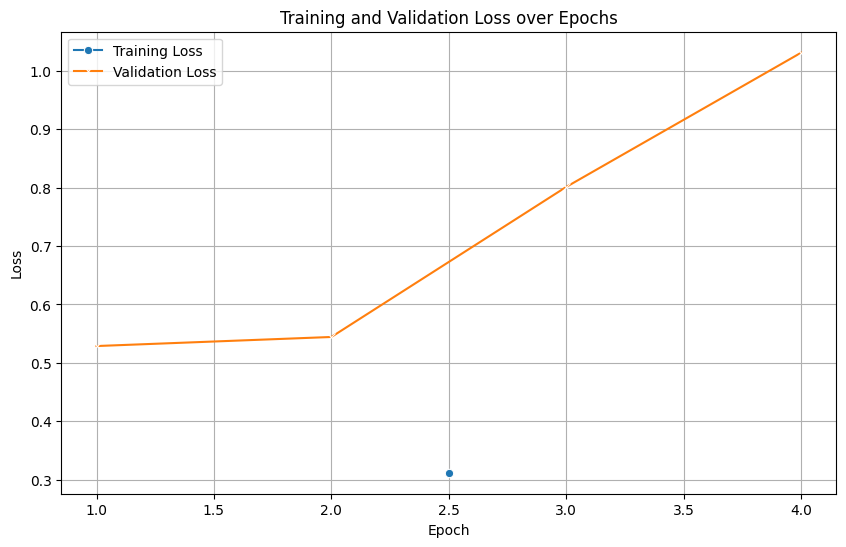

In [17]:
# Extract loss values from the trainer's log history
# Ensure the trainer has completed its training to have a populated history

log_history = trainer.state.log_history

train_losses = []
val_losses = []
epochs = []

for log in log_history:
    if 'loss' in log: # Training loss
        train_losses.append(log['loss'])
        epochs.append(log['epoch'])
    if 'eval_loss' in log: # Validation loss
        val_losses.append(log['eval_loss'])

# Adjust epochs for validation losses if they are logged at different frequencies
# Assuming eval_loss is logged once per epoch at the end, aligning with 'epoch' in training logs

# Filter out duplicate epochs or ensure one entry per epoch if necessary
# For simplicity, we'll assume a direct correspondence if lengths match for now.
# If lengths mismatch, more sophisticated alignment might be needed (e.g., using 'step' or 'epoch' directly from eval logs)

# Since eval_strategy='epoch' and save_strategy='epoch', eval_loss should correspond to the end of each epoch.
# Let's collect epoch numbers for both to be precise.

train_epochs = []
val_epochs = []
actual_train_losses = []
actual_val_losses = []

for log_entry in log_history:
    if 'loss' in log_entry and 'epoch' in log_entry: # Training loss (often logged multiple times per epoch)
        # We want one point per epoch for training loss, typically the last one or average
        # For simplicity, we'll take the last reported training loss for each epoch.
        # A more robust way would be to group by epoch and take the mean/last.
        if log_entry['epoch'] not in train_epochs:
            train_epochs.append(log_entry['epoch'])
            actual_train_losses.append(log_entry['loss'])
        else:
            # Update with the latest loss for this epoch
            idx = train_epochs.index(log_entry['epoch'])
            actual_train_losses[idx] = log_entry['loss']

    if 'eval_loss' in log_entry and 'epoch' in log_entry: # Validation loss (once per epoch)
        val_epochs.append(log_entry['epoch'])
        actual_val_losses.append(log_entry['eval_loss'])

# Plotting
plt.figure(figsize=(10, 6))
sns.lineplot(x=train_epochs, y=actual_train_losses, label='Training Loss', marker='o')
sns.lineplot(x=val_epochs, y=actual_val_losses, label='Validation Loss', marker='x')

plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## 5. Evaluación

In [12]:
trainer.evaluate()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_13606/2732109216.py", line 1, in <cell line: 0>
    trainer.evaluate()
  File "/usr/local/lib/python3.12/dist-packages/transformers/trainer.py", line 4289, in evaluate
    output = self.evaluation_loop(
             ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/transformers/trainer.py", line 4477, in evaluation_loop
    losses, logits, labels = self.prediction_step(model, inputs, prediction_loss_only, ignore_keys=ignore_keys)
                             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/transformers/trainer.py", line 4687, in prediction_step
    loss, outputs = self.compute_loss(
                    ^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/

TypeError: object of type 'NoneType' has no len()